# Categorical Recurrence (catRQA) Analysis

This notebook visualizes the outputs of the `04_catRQA.py` script. We will:
1. Plot the distributions of Recurrence Rate (RR), Determinism (DET), and Laminarity (LAM) across sessions.
2. Analyze catRQA metrics by dominant regime class.
3. Aggregate metrics to the dyad level and examine correlations with coupling and directionality.

In [70]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import kruskal, spearmanr
import scikit_posthocs as sp
import yaml

# Global plotting style
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["svg.fonttype"] = "none"  # Editable text in SVG

# --- 1. Load Data and Configuration ---
# Load analysis configuration to get paths
# The project root is assumed to be the parent of the 'notebooks' directory
project_root = Path.cwd().parent
with open(project_root / "configs/analysis.yaml") as f:
    cfg = yaml.safe_load(f)

# Get paths for joint affect catRQA and HMM artifacts
ja_cfg = cfg["analysis"]["joint_affect_catrqa"]
out_dir = project_root / ja_cfg["out_dir"]
hmm_dir = project_root / ja_cfg["hmm_dir"]
# Create a directory to save figures from this notebook
figure_dir = project_root / "artifacts" / "joint_affect_catRQA" / "notebook_figures"
figure_dir.mkdir(parents=True, exist_ok=True)

# Load episode-level catRQA results generated by the main script
episode_df = pd.read_csv(out_dir / "catrqa_episode_results.csv")

# Load HMM model parameters to interpret the latent regimes
with open(hmm_dir / "best_model.json") as f:
    hmm_params = json.load(f)

# Define human-readable regime classes based on HMM emission probabilities
pT = np.array(hmm_params["pT"])  # Therapist emission probabilities
pC = np.array(hmm_params["pC"])  # Client emission probabilities
regime_classes = []
for k in range(pT.shape[0]):
    # Classify based on therapist and client valence (Negative, Neutral, Positive)
    therapist_valence = ["Tneg", "Tneu", "Tpos"][np.argmax(pT[k, :])]
    client_valence = ["Cneg", "Cneu", "Cpos"][np.argmax(pC[k, :])]
    regime_classes.append(f"{therapist_valence}-{client_valence}")

# Create the main analysis table, selecting only the shuffle-related null model results
episode_df["regime_class"] = episode_df["regime"].map(lambda r: regime_classes[r])
analysis_df = episode_df[["session_id", "dyad_id", "regime", "regime_class", "duration", 
                            "RR_shuffle", "DET_shuffle", "LAM_shuffle",
                            "RR_Z_shuffle", "DET_Z_shuffle", "LAM_Z_shuffle",
                            "RR_p_shuffle", "DET_p_shuffle", "LAM_p_shuffle",
                            ]]

print("Analysis table created with shape:", analysis_df.shape)
analysis_df.head()

# save as CSV for easier access in future analyses
analysis_df.to_csv(project_root / "artifacts" / "joint_affect_catRQA" / "catrqa_analysis_table.csv", index=False)

Analysis table created with shape: (3408, 14)



---
## 2. Basic Quality Control (QC)
Here we perform some basic checks on the episode data.


Total number of episodes: 3408

Episode counts per regime:
regime
2    1506
3     214
4     298
5     306
6     520
7     564
Name: count, dtype: int64

Episode counts per regime class:
regime_class
Tneu-Cneg    1506
Tpos-Cneu     564
Tneg-Cneu     520
Tneg-Cneg     306
Tpos-Cneg     298
Tneu-Cpos     214
Name: count, dtype: int64

Total time (duration) in each regime:
regime
2    26780
3     4022
4     4699
5     5868
6     8896
7     8138
Name: duration, dtype: int64


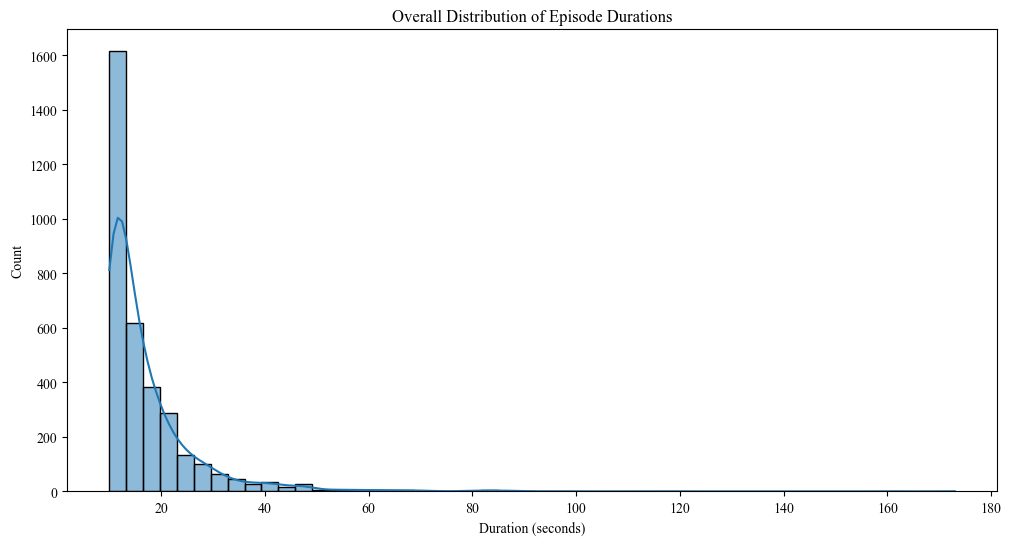

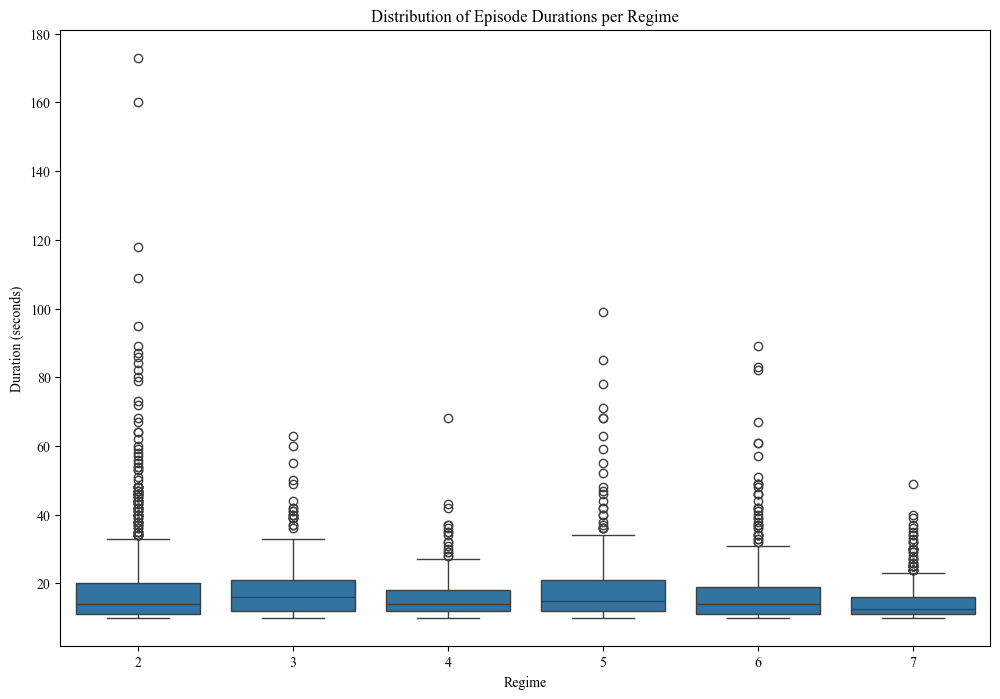


Checking if catRQA metrics are in [0, 1]:
RR_shuffle min: 0.0833333333333333, RR_shuffle max: 1.0
DET_shuffle min: 0.0, DET_shuffle max: 0.999113475177305
LAM_shuffle min: 0.0, LAM_shuffle max: 0.9995430660269592

Correlation between duration and catRQA metrics (Spearman):
  Duration vs. RR_shuffle: rho=0.033, p=0.053
  Duration vs. DET_shuffle: rho=0.262, p=0.000
  Duration vs. LAM_shuffle: rho=0.346, p=0.000


In [71]:
# Episode distribution and coverage
print(f"Total number of episodes: {len(analysis_df)}")

# Episode counts per regime
print("\nEpisode counts per regime:")
print(analysis_df["regime"].value_counts().sort_index())

# Episode counts per regime class
print("\nEpisode counts per regime class:")
print(analysis_df["regime_class"].value_counts())

# Total time in each regime
print("\nTotal time (duration) in each regime:")
print(analysis_df.groupby("regime")["duration"].sum().sort_index())

# Distribution of episode durations
plt.figure(figsize=(12, 6))
sns.histplot(analysis_df["duration"], bins=50, kde=True)
plt.title("Overall Distribution of Episode Durations")
plt.xlabel("Duration (seconds)")
plt.savefig(figure_dir / "episode_duration_distribution.svg", format="svg")
plt.show()

# Distribution of episode durations per regime
plt.figure(figsize=(12, 8))
sns.boxplot(data=analysis_df, x="regime", y="duration")
plt.title("Distribution of Episode Durations per Regime")
plt.xlabel("Regime")
plt.ylabel("Duration (seconds)")
plt.savefig(figure_dir / "episode_duration_by_regime.svg", format="svg")
plt.show()

# Confirm RR/DET/LAM are in [0, 1]
print("\nChecking if catRQA metrics are in [0, 1]:")
print(f"RR_shuffle min: {analysis_df['RR_shuffle'].min()}, RR_shuffle max: {analysis_df['RR_shuffle'].max()}")
print(f"DET_shuffle min: {analysis_df['DET_shuffle'].min()}, DET_shuffle max: {analysis_df['DET_shuffle'].max()}")
print(f"LAM_shuffle min: {analysis_df['LAM_shuffle'].min()}, LAM_shuffle max: {analysis_df['LAM_shuffle'].max()}")

# Check correlation between duration and metrics
print("\nCorrelation between duration and catRQA metrics (Spearman):")
for metric in ["RR_shuffle", "DET_shuffle", "LAM_shuffle"]:
    corr, pval = spearmanr(analysis_df["duration"], analysis_df[metric])
    print(f"  Duration vs. {metric}: rho={corr:.3f}, p={pval:.3f}")


---
## 3. Aggregate Metrics
Now, we aggregate the episode-level metrics to the session and dyad levels.


In [72]:
# Aggregate to session-level (length-weighted mean)
def weighted_mean(df, value_col, weight_col):
    # Ensure the weight column has a non-zero sum to avoid division by zero
    total_weight = df[weight_col].sum()
    if total_weight == 0:
        return 0
    return (df[value_col] * df[weight_col]).sum() / total_weight

# Aggregate to session-level using a duration-weighted mean
session_level_metrics = analysis_df.groupby(["session_id", "dyad_id", "regime", "regime_class"]).apply(
    lambda df: pd.Series({
        "RR_wmean": weighted_mean(df, "RR_shuffle", "duration"),
        "DET_wmean": weighted_mean(df, "DET_shuffle", "duration"),
        "LAM_wmean": weighted_mean(df, "LAM_shuffle", "duration"),
        "RR_Z_wmean": weighted_mean(df, "RR_Z_shuffle", "duration"),
        "DET_Z_wmean": weighted_mean(df, "DET_Z_shuffle", "duration"),
        "LAM_Z_wmean": weighted_mean(df, "LAM_Z_shuffle", "duration"),
        "RR_p_wmean": weighted_mean(df, "RR_p_shuffle", "duration"),
        "DET_p_wmean": weighted_mean(df, "DET_p_shuffle", "duration"),
        "LAM_p_wmean": weighted_mean(df, "LAM_p_shuffle", "duration"),
        "total_duration": df["duration"].sum()
    })
).reset_index()

# Aggregate to dyad-level, weighting by the total duration of each session's contribution
dyad_level_metrics = session_level_metrics.groupby(["dyad_id", "regime", "regime_class"]).apply(
    lambda df: pd.Series({
        "RR_wmean": weighted_mean(df, "RR_wmean", "total_duration"),
        "DET_wmean": weighted_mean(df, "DET_wmean", "total_duration"),
        "LAM_wmean": weighted_mean(df, "LAM_wmean", "total_duration"),
        "RR_Z_shuffle": weighted_mean(df, "RR_Z_wmean", "total_duration"),
        "DET_Z_shuffle": weighted_mean(df, "DET_Z_wmean", "total_duration"),
        "LAM_Z_shuffle": weighted_mean(df, "LAM_Z_wmean", "total_duration"),
        "RR_p_shuffle": weighted_mean(df, "RR_p_wmean", "total_duration"),
        "DET_p_shuffle": weighted_mean(df, "DET_p_wmean", "total_duration"),
        "LAM_p_shuffle": weighted_mean(df, "LAM_p_wmean", "total_duration"),
        "total_duration": df["total_duration"].sum()
    })
).reset_index()

print("Dyad-level metrics:")
dyad_level_metrics.head()

Dyad-level metrics:


/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_27323/1539546226.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  session_level_metrics = analysis_df.groupby(["session_id", "dyad_id", "regime", "regime_class"]).apply(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_27323/1539546226.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dyad_level_metrics = session_level_metrics.groupby(["dyad_

,dyad_id,regime,regime_class,RR_wmean,DET_wmean,LAM_wmean,RR_Z_shuffle,DET_Z_shuffle,LAM_Z_shuffle,RR_p_shuffle,DET_p_shuffle,LAM_p_shuffle,total_duration
0,1,2,Tneu-Cneg,0.874194,0.917775,0.959202,0.301375,-0.087532,0.037941,0.889173,0.701693,0.641967,31.0
1,1,5,Tneg-Cneg,0.611111,0.818182,0.909091,-1.445787,0.818659,0.947274,0.950495,0.376238,0.326733,10.0
2,1,6,Tneg-Cneu,0.769944,0.865314,0.930522,-0.355077,0.181503,0.315135,0.887880,0.565586,0.523114,145.0
3,1,7,Tpos-Cneu,0.825524,0.889449,0.948472,0.473160,-0.039893,0.123176,0.810081,0.702520,0.650135,110.0
4,2,2,Tneu-Cneg,0.778599,0.819530,0.893510,0.666794,-0.388544,-0.465982,0.579915,0.861386,0.928571,56.0


In [73]:
# Establish a consistent regime-class order using the same canonical ordering as hmm_outputs
## (sort by therapist valence, then client valence, with a hash tie-break on emissions)
therapist_valence = np.argmax(pT, axis=1)
client_valence = np.argmax(pC, axis=1)
sort_key = (
    therapist_valence * 1_000_000
    + client_valence * 1_000
    + np.array([(hash(str(pT[k])) + hash(str(pC[k]))) % 1000 for k in range(pT.shape[0])])
)
order = np.argsort(sort_key)
order_rank = {reg: i for i, reg in enumerate(order)}  # canonical numbering matches hmm_outputs

# Regime labels (with duplicate handling) match hmm_outputs
base_labels = []
for k in order:
    t_val = ["Tneg", "Tneu", "Tpos"][therapist_valence[k]]
    c_val = ["Cneg", "Cneu", "Cpos"][client_valence[k]]
    base_labels.append(f"{t_val}-{c_val}")
counts = {}
regime_labels = []
for label in base_labels:
    if base_labels.count(label) > 1:
        counts[label] = counts.get(label, 0) + 1
        regime_labels.append(f"{label}-{counts[label]}")
    else:
        regime_labels.append(label)

# Only include regimes that have catRQA data
catrqa_regimes = set(analysis_df["regime"].unique())
regime_class_by_regime = {k: regime_classes[k] for k in range(len(regime_classes))}
class_order = []
for k in order:
    if k not in catrqa_regimes:
        continue
    rc = regime_class_by_regime[k]
    if rc not in class_order:
        class_order.append(rc)

# Labels with regime numbers using canonical order (only those present in catRQA), e.g., Tneg-Cneg (R2/R5)
class_labels = []
for rc in class_order:
    regs = [idx for idx in order if regime_classes[idx] == rc and idx in catrqa_regimes]
    label_nums = [f"R{order_rank[idx] + 1}" for idx in regs]
    class_labels.append(f"{rc} (" + "/".join(label_nums) + ")")

# Set regime_class as an ordered categorical so all downstream stats/plots share this order
dyad_level_metrics = dyad_level_metrics.copy()
dyad_level_metrics["regime_class"] = pd.Categorical(
    dyad_level_metrics["regime_class"], categories=class_order, ordered=True
)

# Palette by therapist valence for reuse
color_map = {"Tneg": "lightcoral", "Tneu": "lightgray", "Tpos": "lightgreen"}
palette = [color_map[rc.split('-')[0]] for rc in class_order]


---
## 4. Hypothesis Tests
Now we test our main hypotheses about the differences in structure across regimes and the link to coupling/directionality.


Kruskal-Wallis test for RR_Z_shuffle: H = 72.85, p = 0.000
Dunn's post-hoc test for RR_Z_shuffle:
                Tneg-Cneg (R1)  Tneg-Cneu (R2)  Tneu-Cneg (R3)  \
Tneg-Cneg (R1)        1.000000        1.000000    2.022410e-05   
Tneg-Cneu (R2)        1.000000        1.000000    3.095549e-04   
Tneu-Cneg (R3)        0.000020        0.000310    1.000000e+00   
Tneu-Cpos (R6)        0.647667        0.013521    1.701434e-13   
Tpos-Cneg (R7)        1.000000        1.000000    1.133769e-02   
Tpos-Cneu (R8)        0.012479        0.142045    1.000000e+00   

                Tneu-Cpos (R6)  Tpos-Cneg (R7)  Tpos-Cneu (R8)  
Tneg-Cneg (R1)    6.476669e-01        1.000000    1.247938e-02  
Tneg-Cneu (R2)    1.352100e-02        1.000000    1.420450e-01  
Tneu-Cneg (R3)    1.701434e-13        0.011338    1.000000e+00  
Tneu-Cpos (R6)    1.000000e+00        0.004943    3.795828e-08  
Tpos-Cneg (R7)    4.943489e-03        1.000000    9.103229e-01  
Tpos-Cneu (R8)    3.795828e-08        0.910323   

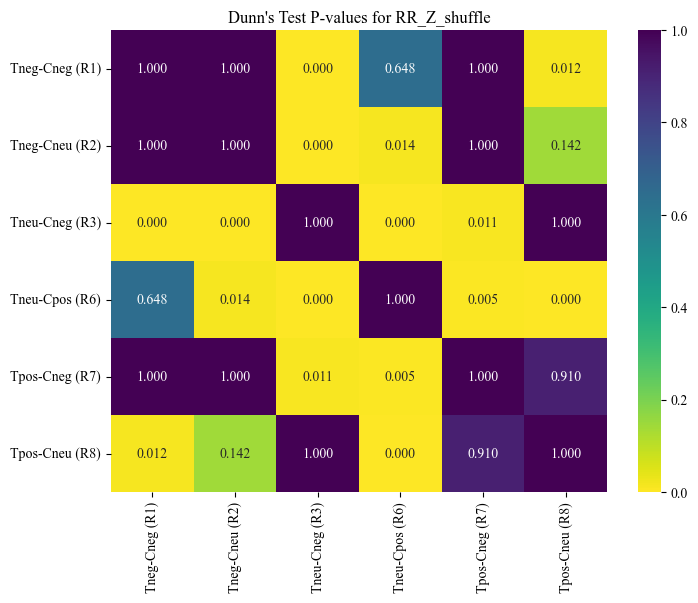

Kruskal-Wallis test for DET_Z_shuffle: H = 40.51, p = 0.000
Dunn's post-hoc test for DET_Z_shuffle:
                Tneg-Cneg (R1)  Tneg-Cneu (R2)  Tneu-Cneg (R3)  \
Tneg-Cneg (R1)        1.000000        1.000000    6.770936e-03   
Tneg-Cneu (R2)        1.000000        1.000000    3.894301e-01   
Tneu-Cneg (R3)        0.006771        0.389430    1.000000e+00   
Tneu-Cpos (R6)        1.000000        0.018358    2.463271e-07   
Tpos-Cneg (R7)        1.000000        1.000000    1.000000e+00   
Tpos-Cneu (R8)        0.063809        1.000000    1.000000e+00   

                Tneu-Cpos (R6)  Tpos-Cneg (R7)  Tpos-Cneu (R8)  
Tneg-Cneg (R1)    1.000000e+00        1.000000        0.063809  
Tneg-Cneu (R2)    1.835847e-02        1.000000        1.000000  
Tneu-Cneg (R3)    2.463271e-07        1.000000        1.000000  
Tneu-Cpos (R6)    1.000000e+00        0.013248        0.000020  
Tpos-Cneg (R7)    1.324804e-02        1.000000        1.000000  
Tpos-Cneu (R8)    1.974562e-05        1.000000 

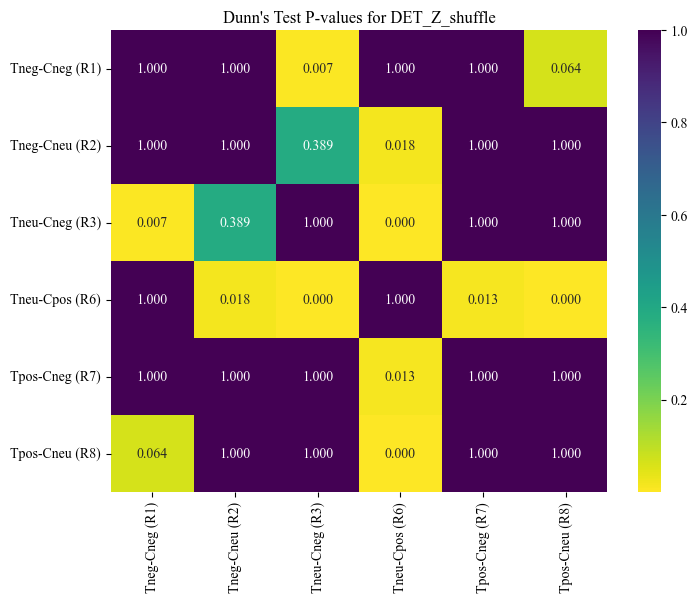

Kruskal-Wallis test for LAM_Z_shuffle: H = 45.97, p = 0.000
Dunn's post-hoc test for LAM_Z_shuffle:
                Tneg-Cneg (R1)  Tneg-Cneu (R2)  Tneu-Cneg (R3)  \
Tneg-Cneg (R1)        1.000000        1.000000    5.285034e-02   
Tneg-Cneu (R2)        1.000000        1.000000    3.013475e-02   
Tneu-Cneg (R3)        0.052850        0.030135    1.000000e+00   
Tneu-Cpos (R6)        0.380139        0.118524    6.574948e-08   
Tpos-Cneg (R7)        1.000000        1.000000    3.964391e-01   
Tpos-Cneu (R8)        0.097246        0.065626    1.000000e+00   

                Tneu-Cpos (R6)  Tpos-Cneg (R7)  Tpos-Cneu (R8)  
Tneg-Cneg (R1)    3.801386e-01        1.000000    9.724581e-02  
Tneg-Cneu (R2)    1.185241e-01        1.000000    6.562644e-02  
Tneu-Cneg (R3)    6.574948e-08        0.396439    1.000000e+00  
Tneu-Cpos (R6)    1.000000e+00        0.035198    4.917651e-07  
Tpos-Cneg (R7)    3.519752e-02        1.000000    6.212582e-01  
Tpos-Cneu (R8)    4.917651e-07        0.621258 

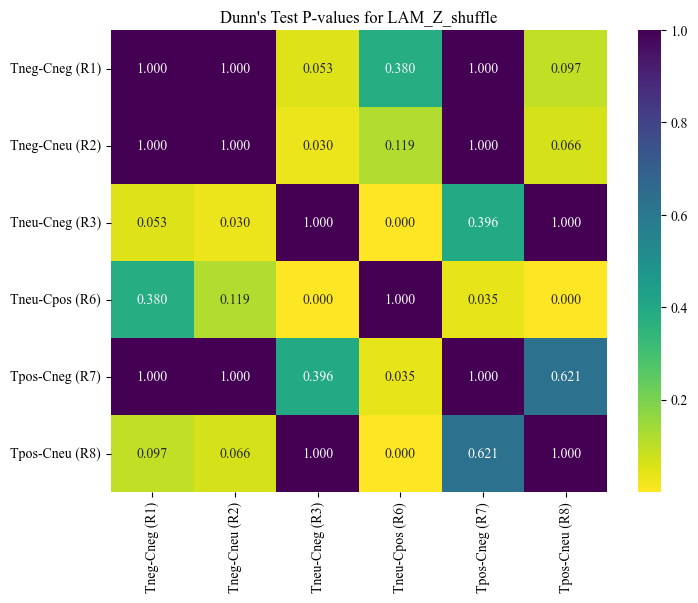


Correlations between structure and coupling/directionality (Spearman):
  DET_Z_shuffle vs. gain_per_trans_wmean: rho=-0.007, p=0.950
  DET_Z_shuffle vs. dT_wmean: rho=0.070, p=0.502
  DET_Z_shuffle vs. dC_wmean: rho=-0.100, p=0.340
  LAM_Z_shuffle vs. gain_per_trans_wmean: rho=-0.055, p=0.603
  LAM_Z_shuffle vs. dT_wmean: rho=0.056, p=0.596
  LAM_Z_shuffle vs. dC_wmean: rho=-0.134, p=0.200


In [78]:
# A) Do regimes differ in structure? (use canonical regime_class order)
for metric in ["RR_Z_shuffle", "DET_Z_shuffle", "LAM_Z_shuffle"]:
    # Kruskal on the ordered regime classes present in catRQA
    groups = [
        dyad_level_metrics.loc[dyad_level_metrics["regime_class"] == rc, metric].values
        for rc in class_order
    ]
    groups = [g for g in groups if len(g) > 0]
    h_stat, p_val = kruskal(*groups)
    print(f"Kruskal-Wallis test for {metric}: H = {h_stat:.2f}, p = {p_val:.3f}")

    # Post-hoc Dunn's test if significant (labels aligned to canonical order)
    if p_val < 0.05:
        dunn_results = sp.posthoc_dunn(
            dyad_level_metrics, val_col=metric, group_col="regime_class", p_adjust="bonferroni"
        )
        dunn_results = dunn_results.loc[class_order, class_order]
        dunn_results.index = class_labels
        dunn_results.columns = class_labels

        print(f"Dunn's post-hoc test for {metric}:")
        print(dunn_results)

        plt.figure(figsize=(8, 6))
        sns.heatmap(dunn_results, annot=True, fmt=".3f", cmap="viridis_r")
        plt.title(f"Dunn's Test P-values for {metric}")
        plt.savefig(figure_dir / f"dunn_heatmap_{metric}.svg", format="svg")
        plt.show()

# C) Link to coupling and directionality
# Load coupling/directionality data
coupling_df = pd.read_csv(project_root / "artifacts" / "coupling_by_dyad.csv")
directionality_df = pd.read_csv(project_root / "artifacts" / "directionality_by_dyad.csv")

# For simplicity, let's focus on overall DET_Z and LAM_Z per dyad
dyad_structure = dyad_level_metrics.groupby("dyad_id")[["DET_Z_shuffle", "LAM_Z_shuffle"]].mean().reset_index()

# Merge with coupling and directionality data
merged_df = pd.merge(dyad_structure, coupling_df, on="dyad_id")
merged_df = pd.merge(merged_df, directionality_df, on="dyad_id")

print("\nCorrelations between structure and coupling/directionality (Spearman):")
for struct_metric in ["DET_Z_shuffle", "LAM_Z_shuffle"]:
    for dir_metric in ["gain_per_trans_wmean", "dT_wmean", "dC_wmean"]:
        corr, pval = spearmanr(merged_df[struct_metric], merged_df[dir_metric])
        print(f"  {struct_metric} vs. {dir_metric}: rho={corr:.3f}, p={pval:.3f}")


---
## 5. Figures
Finally, we create the visualizations to summarize our findings.


/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_27323/360309877.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_27323/360309877.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


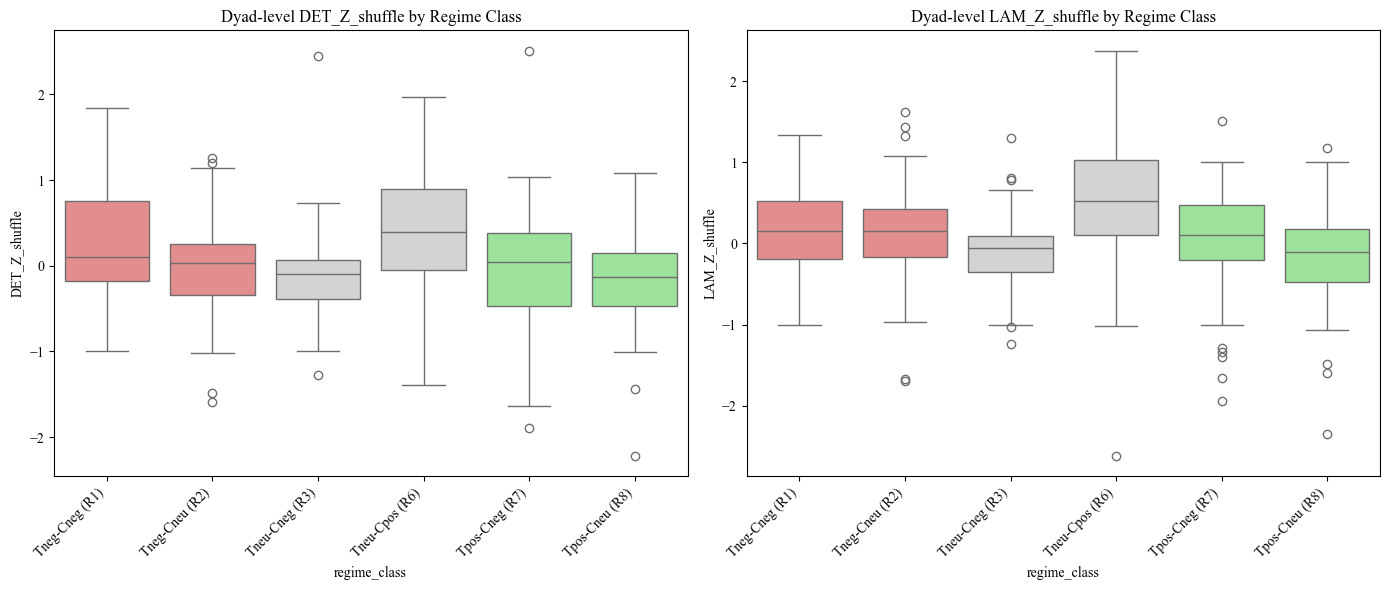

In [75]:
# Distribution of dyad-level DET_Z and LAM_Z by regime class (using consistent ordering/palette)
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(
    data=dyad_level_metrics,
    x="regime_class",
    y="DET_Z_shuffle",
    order=class_order,
    palette=palette,
)
plt.title("Dyad-level DET_Z_shuffle by Regime Class")
plt.xticks(ticks=range(len(class_order)), labels=class_labels, rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.boxplot(
    data=dyad_level_metrics,
    x="regime_class",
    y="LAM_Z_shuffle",
    order=class_order,
    palette=palette,
)
plt.title("Dyad-level LAM_Z_shuffle by Regime Class")
plt.xticks(ticks=range(len(class_order)), labels=class_labels, rotation=45, ha='right')
plt.tight_layout()
plt.savefig(figure_dir / "boxplot_Z_by_regime_class.svg", format="svg")
plt.show()

In [77]:
# Which regimes exist in HMM vs. catRQA?
all_regimes = list(range(len(regime_classes)))
catrqa_regimes = sorted(analysis_df["regime"].unique())

print("All HMM regimes:", [f"R{r+1}" for r in all_regimes])
print("Regimes with catRQA data:", [f"R{r+1}" for r in catrqa_regimes])

# Presence by regime with class labels
for r in all_regimes:
    present = r in catrqa_regimes
    print(f"R{r+1}: {regime_classes[r]}  present_in_catrqa={present}")

All HMM regimes: ['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8']
Regimes with catRQA data: ['R3', 'R4', 'R5', 'R6', 'R7', 'R8']
R1: Tneu-Cneu  present_in_catrqa=False
R2: Tneu-Cneu  present_in_catrqa=False
R3: Tneu-Cneg  present_in_catrqa=True
R4: Tneu-Cpos  present_in_catrqa=True
R5: Tpos-Cneg  present_in_catrqa=True
R6: Tneg-Cneg  present_in_catrqa=True
R7: Tneg-Cneu  present_in_catrqa=True
R8: Tpos-Cneu  present_in_catrqa=True
